# Inference Recorder Review
This notebook is focused on visually checking what the inference recorder is saving.
It is intentionally exploratory and tolerant to partial runs.

In [2]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    discover_recorder_payloads,
    list_recorder_files,
    extract_decoder_deformable_attention,
    load_recorder_payload,
    resolve_image_bank_path,
    payload_summary_frame,
    activation_inventory_frame,
    decoder_attention_summary_frame,
    aggregate_batch_decoder_attention_query_profiles,
    compute_batch_decoder_attention_query_profiles,
    compute_decoder_attention_query_profiles,
    plot_scanpath_overview,
    plot_attention_heatmap,
    plot_sampling_locations,
    plot_batch_decoder_attention_query_profiles,
    plot_decoder_deformable_attention_overlay,
    plot_decoder_attention_query_profiles,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath')

In [3]:
all_pt_files = list_recorder_files()
# display(all_pt_files.head(20))

recorder_files = discover_recorder_payloads(limit=50)
# display(recorder_files)

if recorder_files.empty:
    print('No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.')

In [4]:
selected_path = None
if not recorder_files.empty:
    selected_path = PROJECT_ROOT / recorder_files.iloc[0]['file']
selected_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-20/22-34-13/inference_records/val_epoch_0120_batch_00053_Combined.pt')

## Decoder Deformable Attention Overlay
This section is focused on `decoder.#.second_cross_attn` only.
The origin is reconstructed from teacher-forced fixation coordinates, so query `0` starts at `(0.5, 0.5)` and later queries start at the previous ground-truth fixation.
The `eye_decoder.#.cross_attn` branch is intentionally left out for this iteration.

In [5]:
external_record_dir = Path(r'outputs\outputs\2026-03-20\22-34-13\inference_records')
external_candidates = sorted(external_record_dir.glob('*.pt')) if external_record_dir.exists() else []
payload_path = external_candidates[-1] if external_candidates else selected_path
sample_index = 1
decoder_layer = 3
query_index = 4
aggregate_heads = False
head_index = None
image_bank_path = None

payload_path

WindowsPath('outputs/outputs/2026-03-20/22-34-13/inference_records/val_epoch_0180_batch_00053_Combined.pt')

In [6]:
payload = None
if payload_path is not None:
    payload = load_recorder_payload(payload_path)
    # display(payload.get('metadata', {}))
    # display(payload_summary_frame(payload))
    try:
        resolved_image_bank_path = resolve_image_bank_path(payload_path=payload_path, image_bank_path=image_bank_path)
        print('image_bank_path =', resolved_image_bank_path)
    except FileNotFoundError as exc:
        resolved_image_bank_path = None
        print(exc)

image_bank_path = C:\Users\ulloa\Miooooo\Master\thesis\projectes\From-Noisy-Eye-Tracking-To-Scanpath\data\Coco FreeView\all_images_256.pth


In [7]:
for key, values in (list(payload["activations"].values())[-1]).items():
    print(key, type(values))

sampling_offsets <class 'list'>
attention_weights <class 'list'>
sampling_locations <class 'list'>
reference_points <class 'list'>


In [8]:
len((list(list(payload["activations"].values())[-1].values())[0]))

12

In [9]:
decoder_attention_info = None
if payload is not None:
    decoder_attention_info = extract_decoder_deformable_attention(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
    )
    # display({
    #     'module_name': decoder_attention_info['module_name'],
    #     'query_count': decoder_attention_info['query_count'],
    #     'num_heads': decoder_attention_info['num_heads'],
    #     'num_points': decoder_attention_info['num_points'],
    #     'valid_fixation_count': decoder_attention_info['valid_fixation_count'],
    #     'is_terminal_or_padded': decoder_attention_info['is_terminal_or_padded'],
    #     'selected_head_index': decoder_attention_info['selected_head_index'],
    # })
    # display(decoder_attention_summary_frame(
    #     payload,
    #     sample_index=sample_index,
    #     decoder_layer=decoder_layer,
    #     query_index=query_index,
    #     aggregate_heads=aggregate_heads,
    #     head_index=head_index,
    # ))

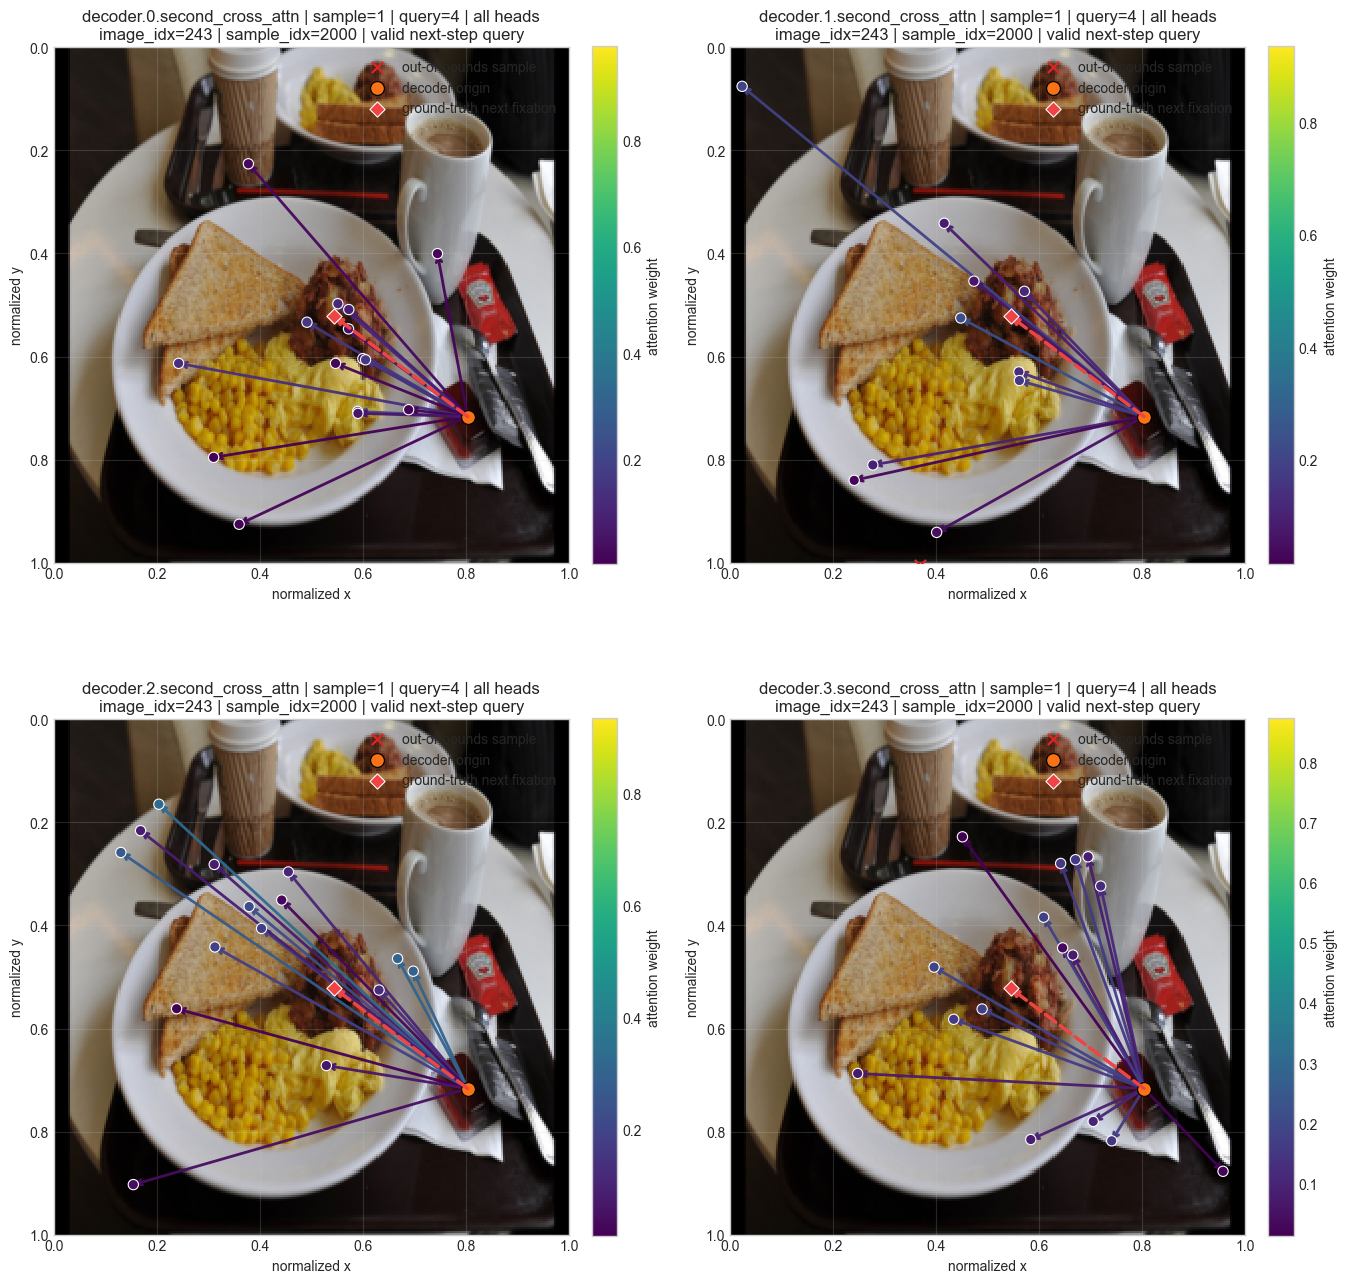

In [10]:
if payload is not None:
    fig, ax = plt.subplots(2,2,figsize = (16,16))
    item_count = 0
    for i in range(2):
        for j in range(2):

            plot_decoder_deformable_attention_overlay(
                payload,
                ax=ax[i,j],
                sample_index=sample_index,
                decoder_layer=item_count,
                query_index=query_index,
                aggregate_heads=aggregate_heads,
                head_index=head_index,
                payload_path=payload_path,
                image_bank_path=image_bank_path,
            )
            item_count += 1

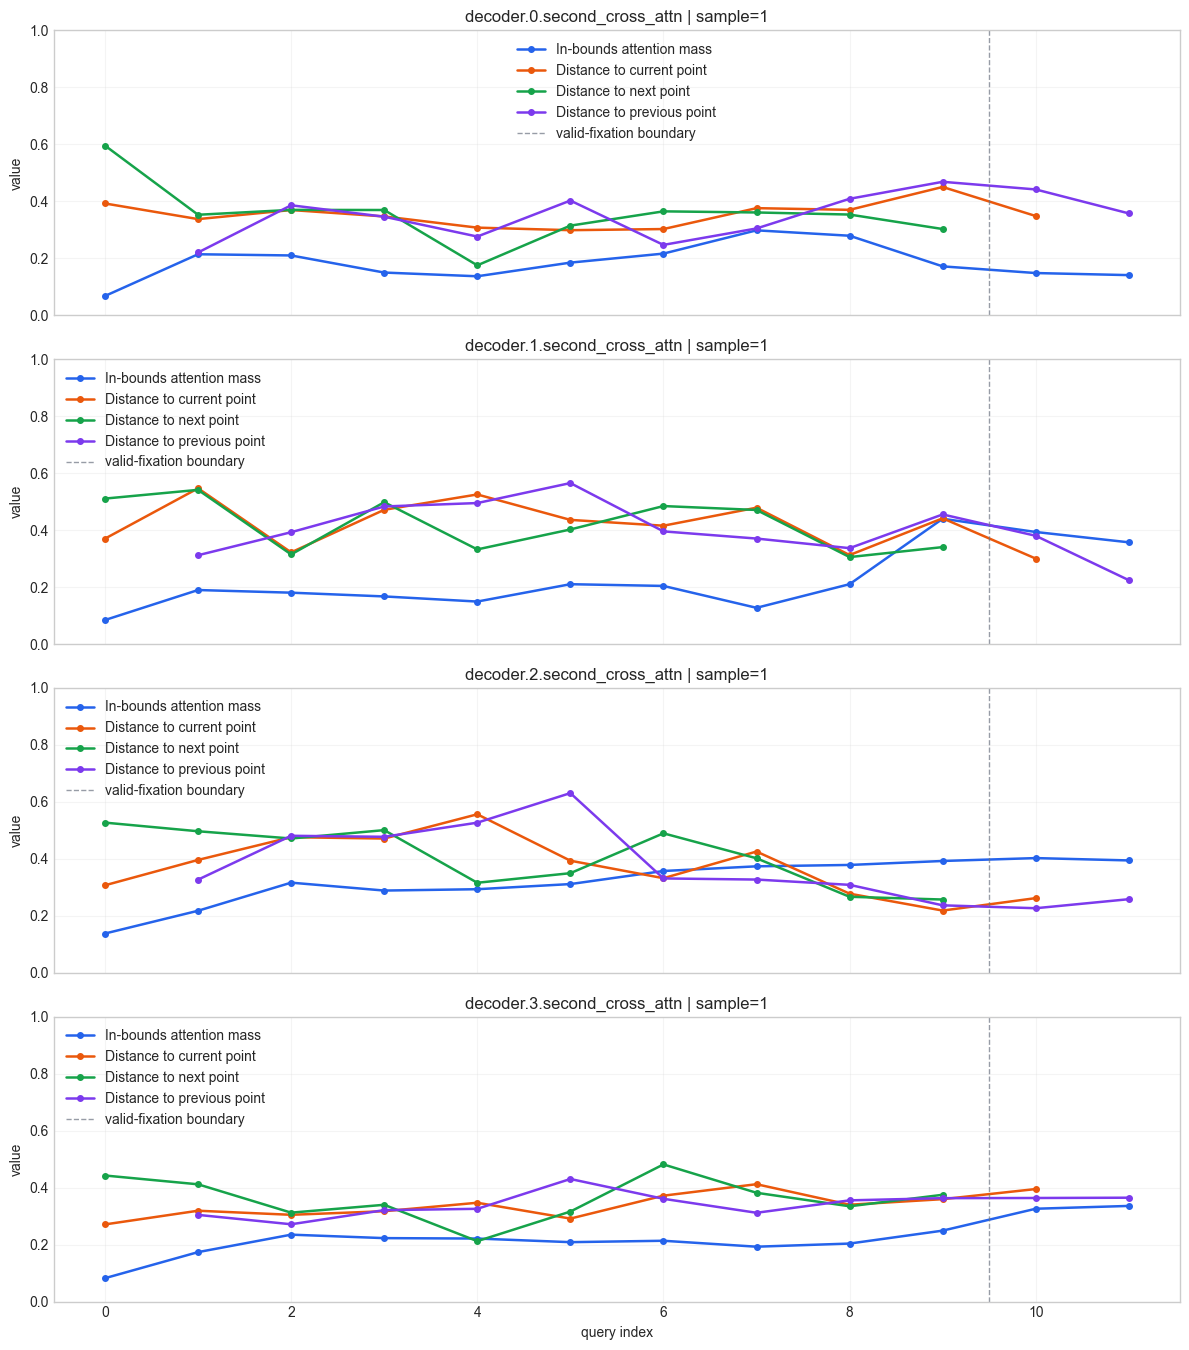

In [11]:
if payload is not None:
    decoder_query_profiles = plot_decoder_attention_query_profiles(
        payload,
        sample_index=sample_index,
    )
    # display(decoder_query_profiles)


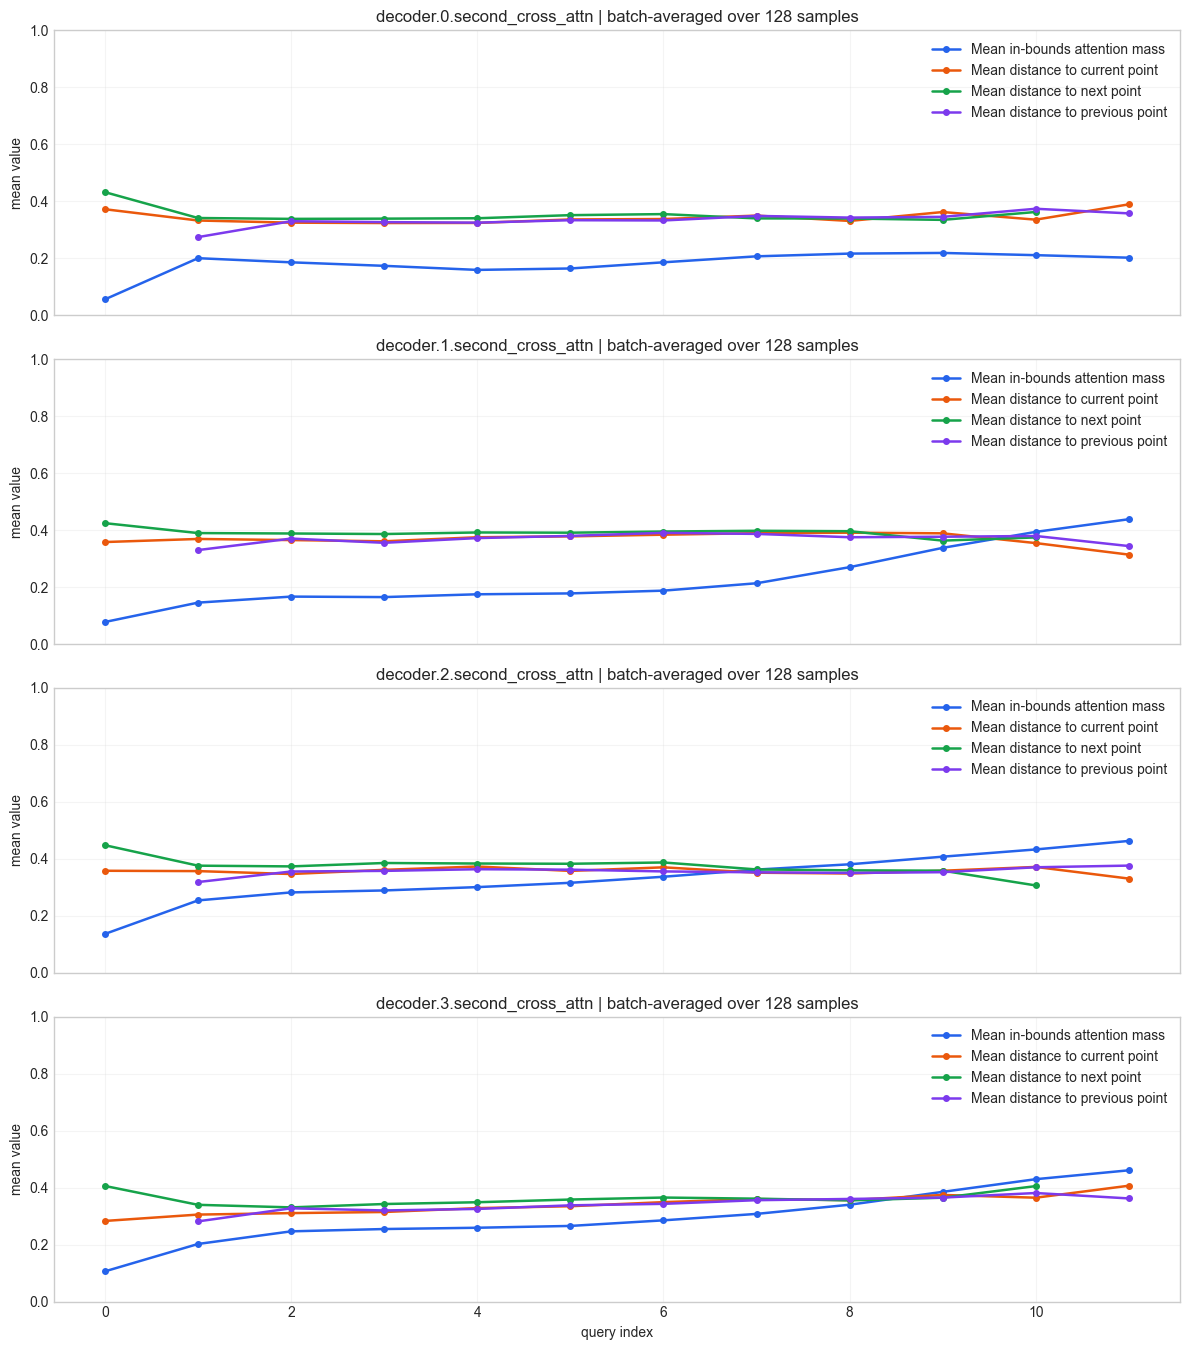

In [12]:
if payload is not None:
    batch_decoder_query_profiles = plot_batch_decoder_attention_query_profiles(payload)
    # display(batch_decoder_query_profiles)


In [13]:
#if payload is not None:
    # display(activation_inventory_frame(payload).sort_values(['module', 'activation']).reset_index(drop=True))

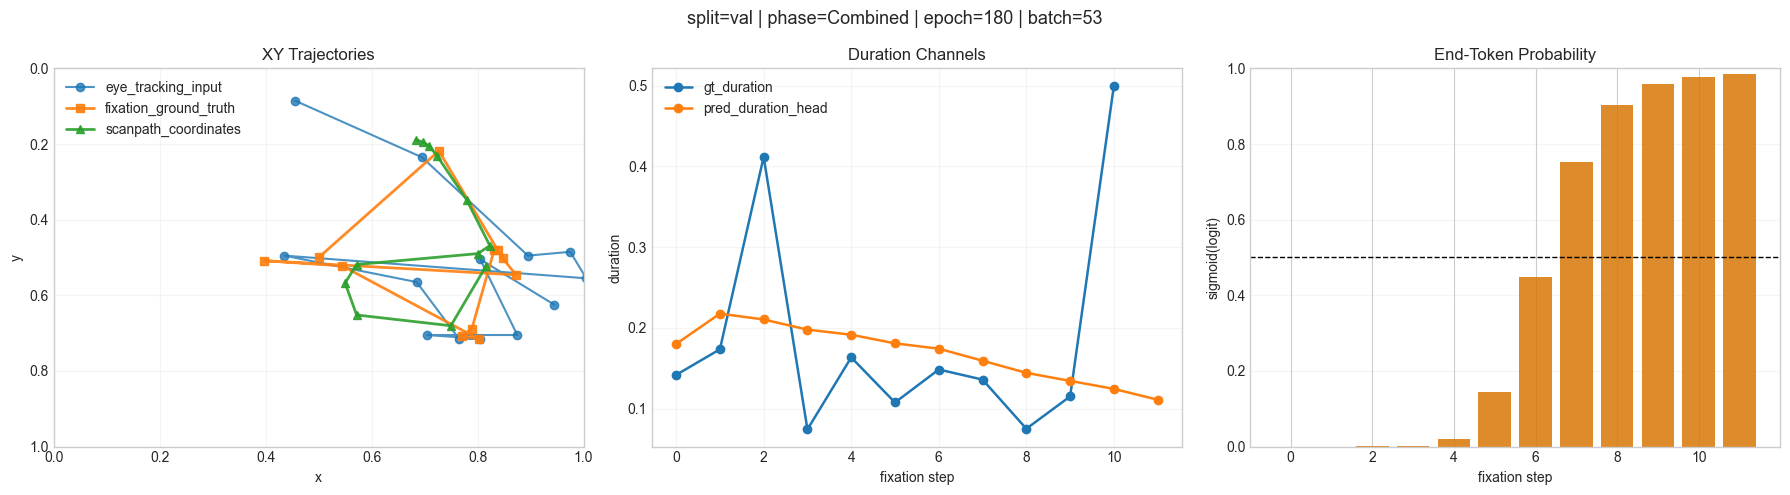

In [14]:
if payload is not None:
    plot_scanpath_overview(payload, sample_index=sample_index)

## Fixation to EyeTracking Cross Attention

In [15]:
from src.data.datasets import FreeViewInMemory
data = FreeViewInMemory()

In [16]:
data.data_store.keys()

dict_keys(['down_gaze', 'filtered_idx', 'fixation_mask', 'fixations', 'gaze'])

In [17]:
payload["data"].keys()

dict_keys(['sample_idx', 'image_idx', 'random_down_offset', 'eye_tracking_input', 'fixation_ground_truth', 'clean_eye_tracking', 'target_padding_mask', 'src_padding_mask'])

In [23]:
from src.preprocess.simulation import downsampling_index
import numpy as np
import random
from src.data.datasets import extract_random_period
# idx = random.randint(0,len(masks))


def downsample_mask(mask):
    fake_gaze = np.zeros((3,len(mask)))
    fake_gaze[2,:] = np.arange(len(mask))*1000/60
    d_idx = downsampling_index(fake_gaze)[0]
    return d_idx



cropped = np.zeros((128, 12,13))

for idx in range(128):
    sample_idx = payload["data"]["sample_idx"]
    masks = data.data_store["fixation_mask"][sample_idx]
    fixation = data.data_store["fixations"][sample_idx]
    down_gaze = data.data_store["down_gaze"][sample_idx]
    d_idx_list = []
    for i in range(masks.shape[0]):    
        d_idx_list.append(downsample_mask(masks[i]))

    d_mask = masks[idx][d_idx_list[idx]]
    print("len: ", len(masks[idx]))
    print("d_len: ", len(d_mask))


    down_offset = payload["data"]["random_down_offset"][idx]
    down_gaze_item = down_gaze[idx].reshape((3, -1)).copy()
    fixation_item = fixation[idx].reshape((3, -1)).copy()

    x, y, start_fixation, end_fixation, _ = extract_random_period(start_index = down_offset, 
                        period_duration = 2600, 
                        noisy_samples = down_gaze_item, 
                        fixations = fixation_item, 
                        fixation_mask = masks[idx], 
                        sampling_rate = 60, 
                        downsample_period = 200, 
                        random_offset=False)

    align = np.zeros((max(d_mask), len(d_mask)))
    for i in range(d_mask.max()):
        align[i, d_mask == (i + 1)] = i + 1


    cropped[idx, :end_fixation + 1 - start_fixation, :] = align[start_fixation:end_fixation + 1,
        down_offset: down_offset + 13]

# plt.imshow(align)
# plt.hlines([start_fixation, end_fixation],xmin = 0,xmax = down_gaze_item.shape[1] - 1,  color = 'r')
# plt.vlines([down_offset, down_offset + 13 - 1], ymin = 0, ymax = fixation_item.shape[1] - 1,color = 'g')


len:  256
d_len:  22
len:  288
d_len:  24
len:  277
d_len:  23
len:  201
d_len:  17
len:  184
d_len:  16
len:  280
d_len:  24
len:  210
d_len:  18
len:  295
d_len:  25
len:  282
d_len:  24
len:  277
d_len:  23
len:  304
d_len:  26
len:  302
d_len:  26
len:  276
d_len:  23
len:  286
d_len:  24
len:  285
d_len:  24
len:  236
d_len:  20
len:  187
d_len:  16
len:  300
d_len:  25
len:  274
d_len:  23
len:  282
d_len:  24
len:  260
d_len:  22
len:  274
d_len:  23
len:  248
d_len:  21
len:  264
d_len:  22
len:  304
d_len:  26
len:  281
d_len:  24
len:  294
d_len:  25
len:  289
d_len:  24
len:  285
d_len:  24
len:  258
d_len:  22
len:  300
d_len:  25
len:  297
d_len:  25
len:  290
d_len:  25
len:  299
d_len:  25
len:  278
d_len:  24
len:  277
d_len:  23
len:  288
d_len:  24
len:  297
d_len:  25
len:  275
d_len:  23
len:  294
d_len:  25
len:  284
d_len:  24
len:  286
d_len:  24
len:  297
d_len:  25
len:  300
d_len:  25
len:  296
d_len:  25
len:  245
d_len:  21
len:  303
d_len:  26
len:  221
d_l

In [19]:
print(start_fixation)
print(end_fixation)

6
13


[]

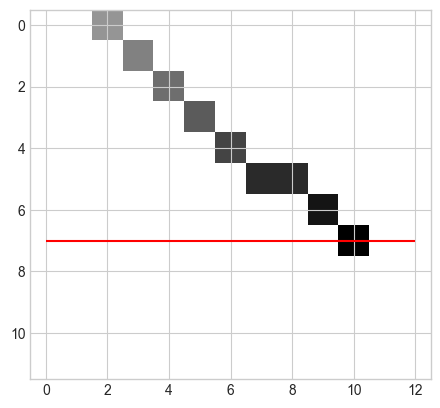

In [20]:
# cropped = np.zeros((12,13))
# 
# cropped[:end_fixation + 1 - start_fixation] = align[start_fixation:end_fixation + 1,
#       down_offset: down_offset + 13]
# 
# plt.imshow(cropped)
# plt.hlines([end_fixation - start_fixation],xmin = 0,xmax = 12,  color = 'r')
# plt.plot()

In [21]:
def compute_location_score(attn, cropped):
    has_fixation = cropped > 0
    has_sample = has_fixation.any(axis = 1)
    total_att_fix = attn.sum(axis = 1)

    copy_not = attn.copy()
    copy_not[np.logical_not(has_fixation)] = 0
    total_att_loc = copy_not.sum(axis = 1)
    return (total_att_loc/total_att_fix)[has_sample].mean()

torch.Size([128, 8, 12, 13])


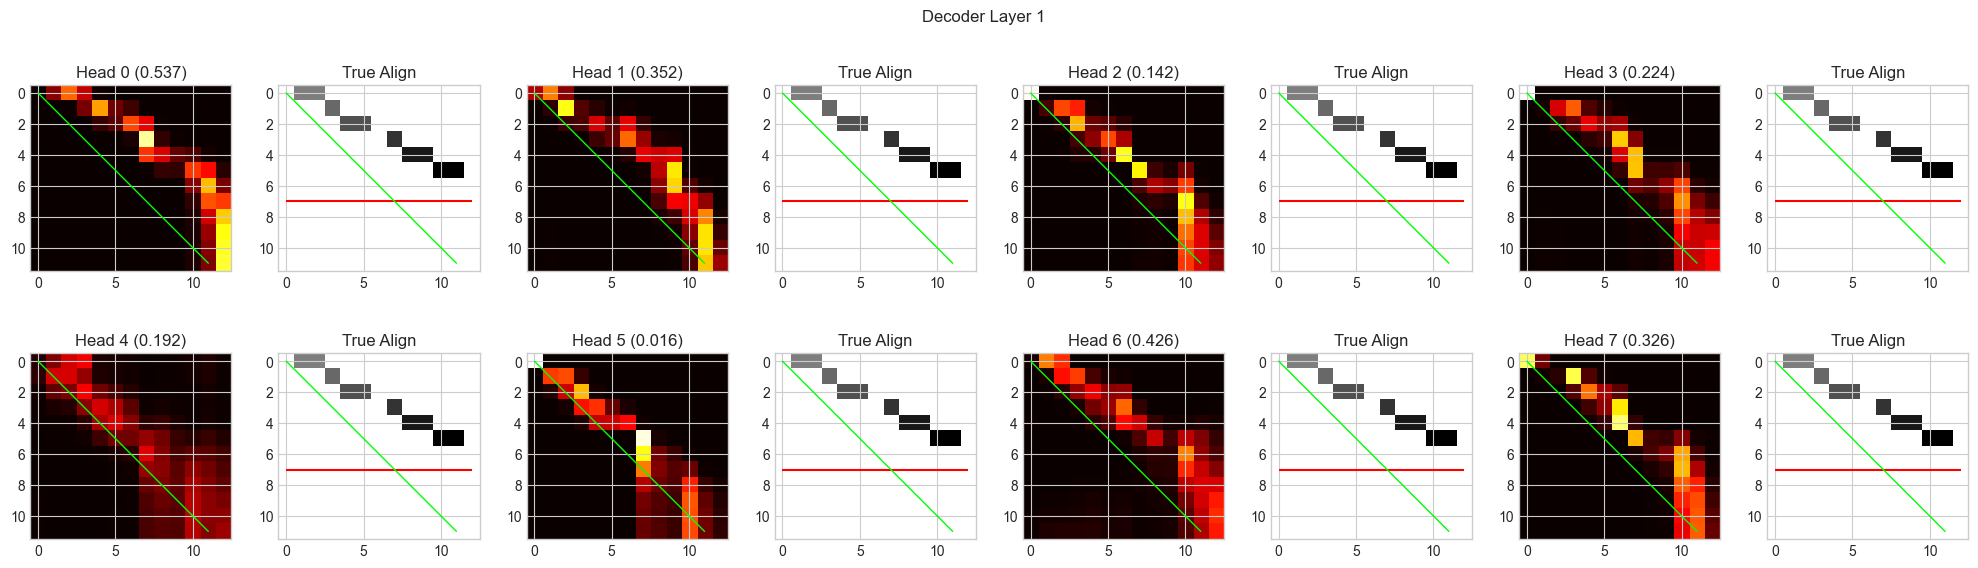

torch.Size([128, 8, 12, 13])


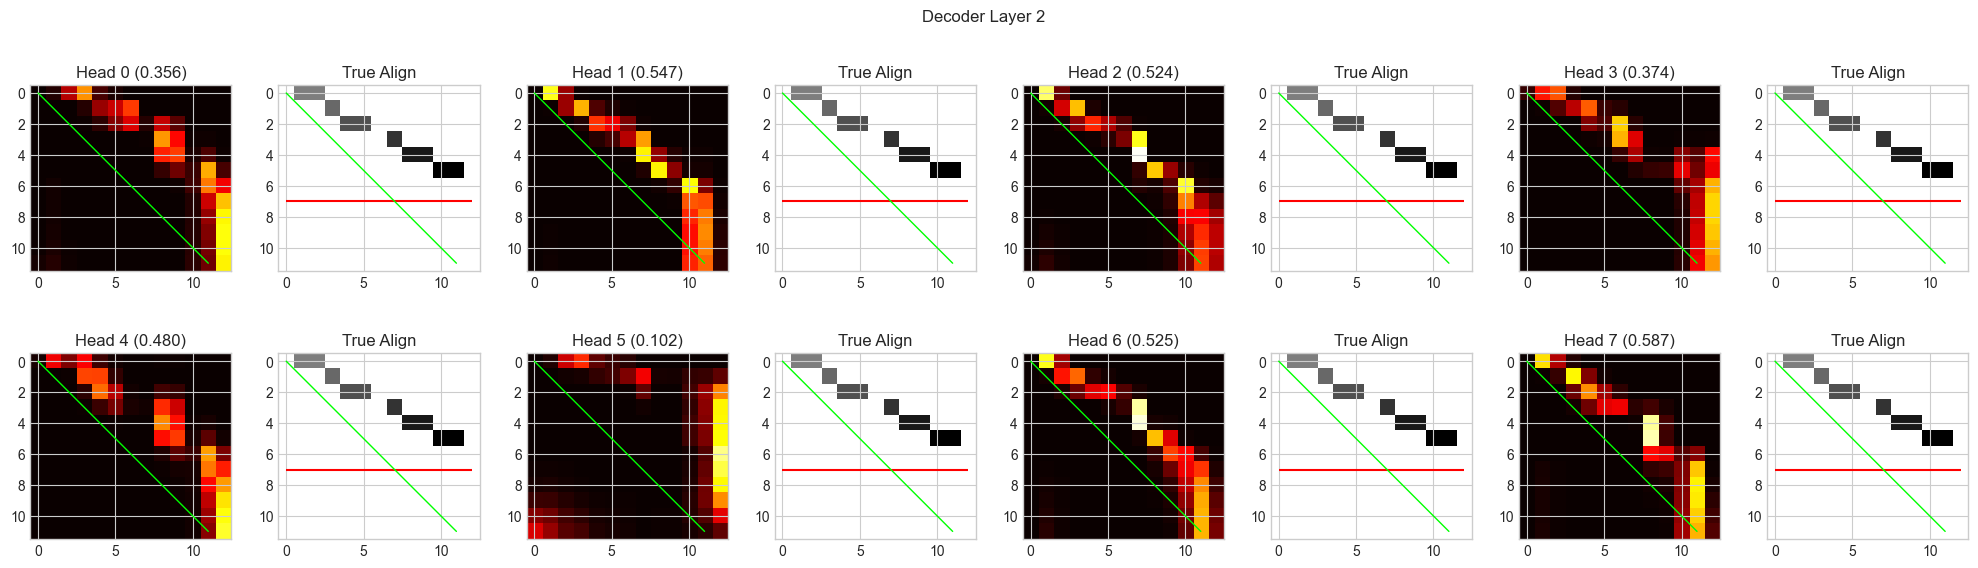

torch.Size([128, 8, 12, 13])


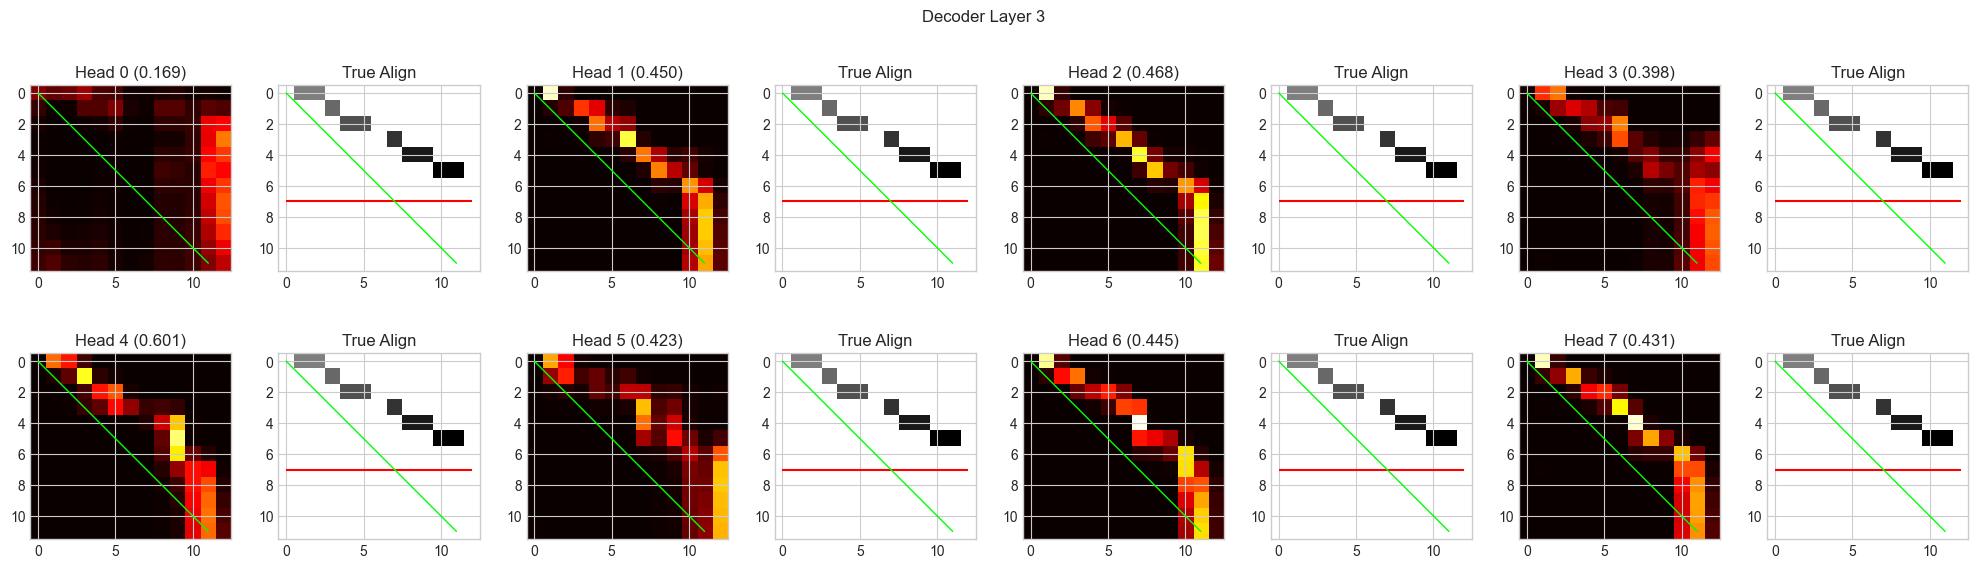

torch.Size([128, 8, 12, 13])


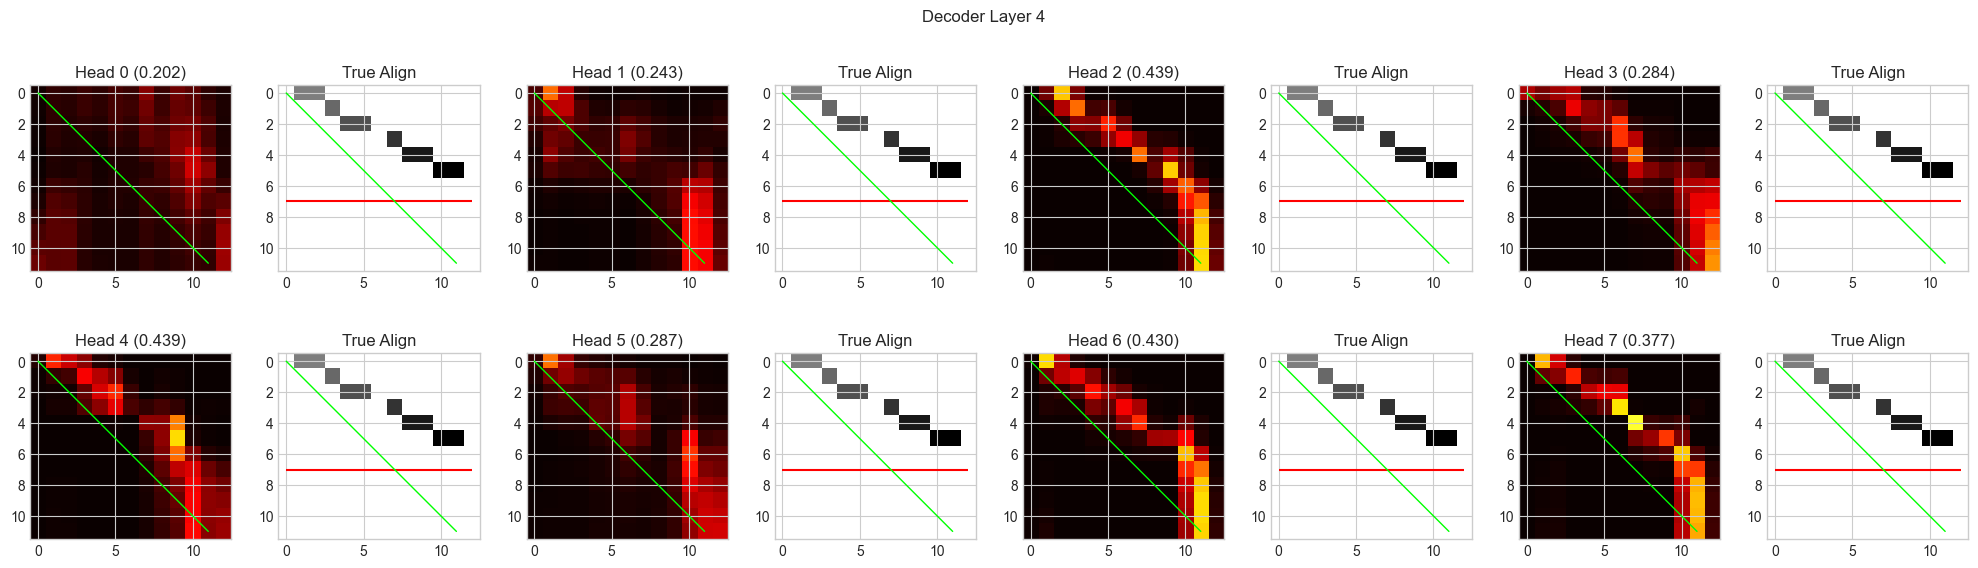

In [25]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import torch
import random
"""
IMPORTANTE
Compute probability distributions of scores per head

"""
mean_over_batch = False
show_align = True
index = 0
attentions = []
for key, values in payload["activations"].items():
    if "first_cross_attn" in key:
        item = values["attention_weights"][-1]
        attentions.append(item)

for k in range(4):
    if show_align:
        fig, axis = plt.subplots(2, 8, figsize=(20, 6))
    else:
        fig, axis = plt.subplots(2, 4, figsize=(20, 6))
    layer = attentions[k]
    print(layer.shape)
    # Compute all heads first so they share the same normalization
    heads = []
    for item_count in range(8):
        if mean_over_batch:
            head = layer[:, item_count, :, :].mean(axis=0)
        else:
            head = layer[index, item_count, :, :]
        heads.append(head.cpu().numpy())
    
    norm = colors.Normalize(vmin=0, vmax=1)

    fig.suptitle(f"Decoder Layer {k + 1}")

    item_count = 0
    im = None
    for i in range(2):
        for j in range(4):
            sizex = heads[item_count].shape[0]
            sizey = heads[item_count].shape[1]
            min_size = min(sizey - 1,sizex - 1)
            
            if show_align:
                # attention
                score = compute_location_score(heads[item_count], cropped[index])
                im = axis[i, j*2].imshow(heads[item_count], cmap="hot", norm=norm)
                axis[i, j*2].plot([0, min_size], [0, min_size], color="lime", linewidth=1)
                axis[i, j*2].set_title(f"Head {item_count} ({score:.3f})")
                # true align
                im = axis[i, j*2 + 1].imshow(cropped[index])
                axis[i, j*2 + 1].hlines([end_fixation - start_fixation],xmin = 0,xmax = 12,  color = 'r')
                axis[i, j*2 + 1].plot([0, min_size], [0, min_size], color="lime", linewidth=1)
                axis[i, j*2 + 1].set_title(f"True Align")
            else:
                im = axis[i, j].imshow(heads[item_count], cmap="hot", norm=norm)
                axis[i, j].plot([0, min_size], [0, min_size], color="lime", linewidth=1)
                axis[i, j].set_title(f"Head {item_count}")

            item_count += 1

    # One shared colorbar for the whole figure
    # fig.colorbar(im, ax=axis, shrink=0.8)
    plt.tight_layout()
    plt.show()

## Notes
- `data` comes from `InferenceRecorder.record_batch` and currently includes indices plus input/target tensors when present.
- `outputs` includes `denoise`, `coord`, `dur`, `reg`, and `cls` under more descriptive names.
- `activations` currently come from attention modules in `blocks.py`, mainly cross-attention weights and deformable-attention sampling tensors.